In [1]:
import os
import sys
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path

sys.path.insert(0, '../src')
from utils import geosoft_cmap_k65
geosoft_cmap = geosoft_cmap_k65()

BASE = '/Users/jrines/stanford_gp/research/mx/computers_geosciences/revision01/sherlock'


In [2]:
# --- Load all results ---
BASE = '/Users/jrines/stanford_gp/research/mx/computers_geosciences/revision01/sherlock'

# MGSIM ensembles (5 configs)
mgsim_configs = [
    'iso_subregions_dense',
    'iso_global_dense',
    'aniso_subregions_dense',
    'aniso_global_dense',
    'iso_subregions_sparse',
]

mgsim_means = {}
for cfg in mgsim_configs:
    combined = f'{BASE}/{cfg}/{cfg}_combined.nc'
    if os.path.exists(combined):
        ds = xr.open_dataset(combined)
    else:
        # Concatenate from chunks
        files = sorted(Path(f'{BASE}/{cfg}').glob('realizations_*.nc'))
        ds = xr.open_mfdataset(files, combine='nested', concat_dim='realization')
    # Compute ensemble mean — adjust variable name as needed
    var_name = [v for v in ds.data_vars if 'norm' not in str(v)][0]
    mgsim_means[cfg] = ds[var_name].mean(dim='realization').values
    print(f"Loaded {cfg}: {ds.dims.get('realization', '?')} realizations, var={var_name}")
    ds.close()

# Standard geostats
kriging = {}
sgsim_means = {}
for density in ['dense', 'sparse']:
    # Kriging
    ds_k = xr.open_dataset(f'{BASE}/standard_geostats/{density}/kriging_result.nc')
    kriging[density] = ds_k['kriging_pred'].values
    ds_k.close()

    # SGSIM ensemble mean
    files = sorted(Path(f'{BASE}/standard_geostats/{density}').glob('sgsim_realizations_*.nc'))
    ds_s = xr.open_mfdataset(files, combine='nested', concat_dim='realization')
    sgsim_means[density] = ds_s['simulated'].mean(dim='realization').values
    print(f"Loaded SGSIM {density}: {ds_s.dims['realization']} realizations")
    ds_s.close()

print("All results loaded.")


/var/folders/mr/bgbp776x687gs3ndy2tgrybr0000gn/T/ipykernel_89818/2729696545.py:25: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"Loaded {cfg}: {ds.dims.get('realization', '?')} realizations, var={var_name}")
<frozen _collections_abc>:774: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
/var/folders/mr/bgbp776x687gs3ndy2tgrybr0000gn/T/ipykernel_89818/2729696545.py:25: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, plea

Loaded iso_subregions_dense: 1000 realizations, var=simulated
Loaded iso_global_dense: 1000 realizations, var=simulated


/var/folders/mr/bgbp776x687gs3ndy2tgrybr0000gn/T/ipykernel_89818/2729696545.py:25: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"Loaded {cfg}: {ds.dims.get('realization', '?')} realizations, var={var_name}")
<frozen _collections_abc>:774: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
/var/folders/mr/bgbp776x687gs3ndy2tgrybr0000gn/T/ipykernel_89818/2729696545.py:25: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, plea

Loaded aniso_subregions_dense: 1000 realizations, var=simulated
Loaded aniso_global_dense: 1000 realizations, var=simulated


/var/folders/mr/bgbp776x687gs3ndy2tgrybr0000gn/T/ipykernel_89818/2729696545.py:25: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"Loaded {cfg}: {ds.dims.get('realization', '?')} realizations, var={var_name}")
<frozen _collections_abc>:774: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.


Loaded iso_subregions_sparse: 1000 realizations, var=simulated
Loaded SGSIM dense: 1000 realizations
Loaded SGSIM sparse: 1000 realizations
All results loaded.


/var/folders/mr/bgbp776x687gs3ndy2tgrybr0000gn/T/ipykernel_89818/2729696545.py:41: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"Loaded SGSIM {density}: {ds_s.dims['realization']} realizations")
/var/folders/mr/bgbp776x687gs3ndy2tgrybr0000gn/T/ipykernel_89818/2729696545.py:41: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"Loaded SGSIM {density}: {ds_s.dims['realization']} realizations")


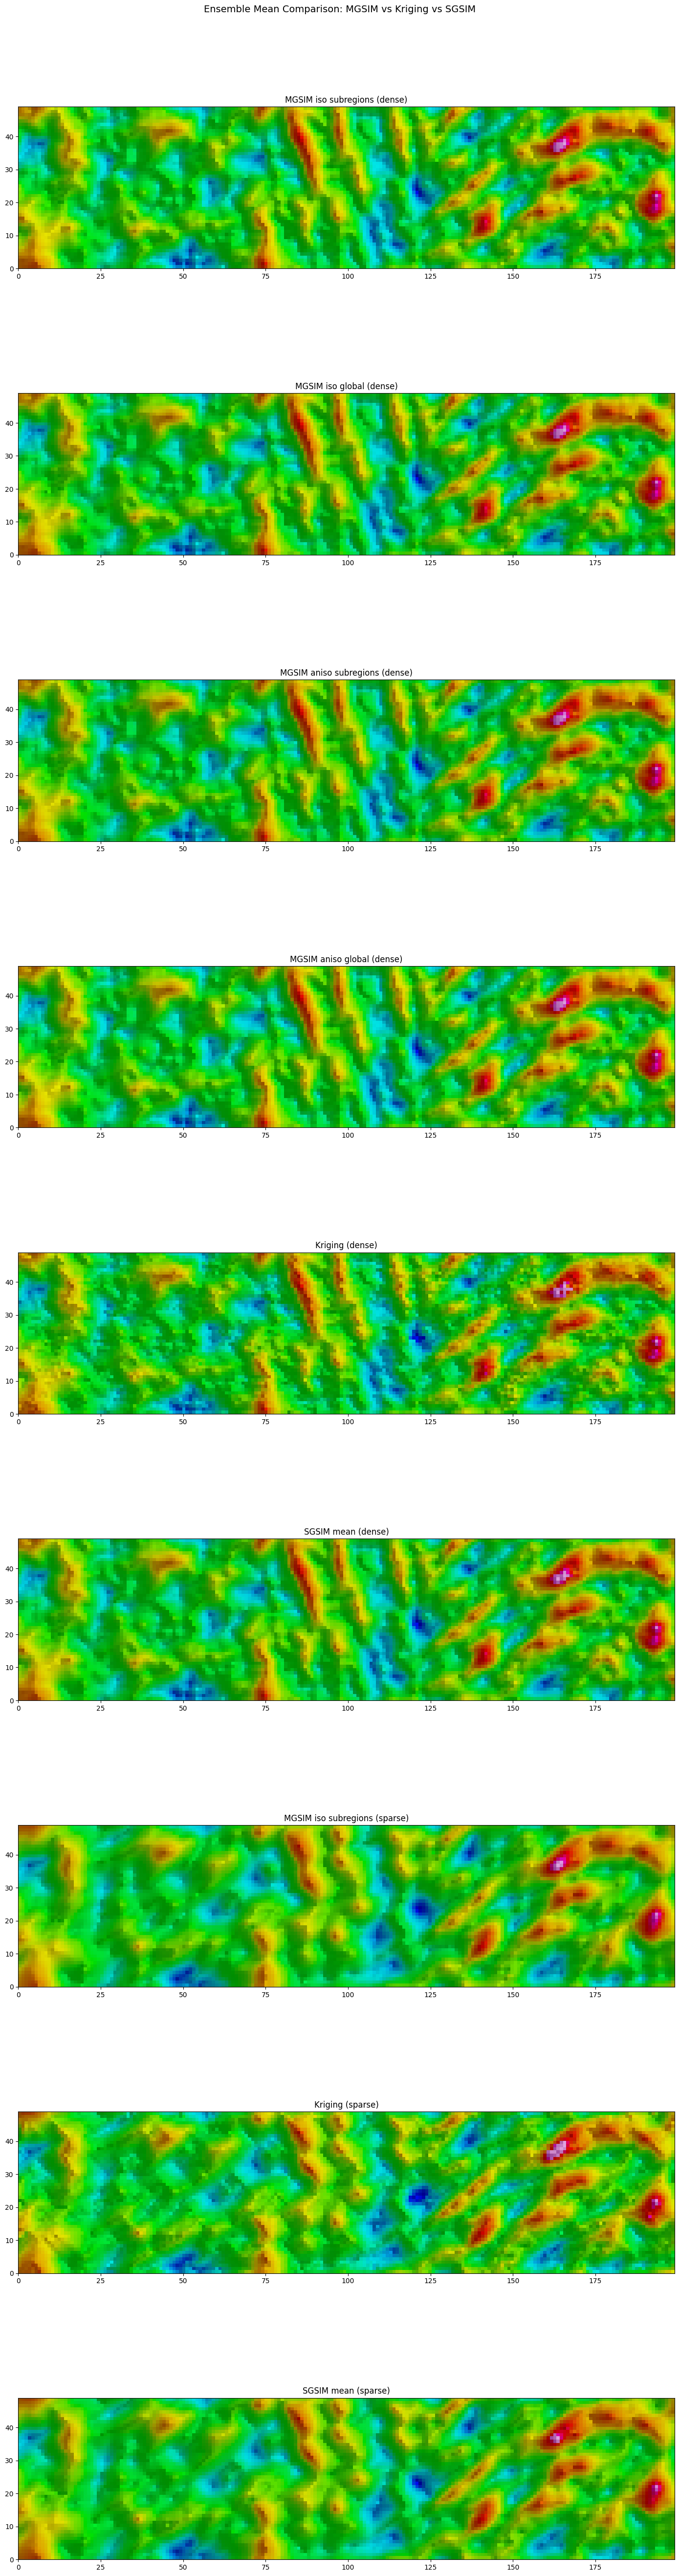

In [5]:
from matplotlib.colors import Normalize, LightSource

ds_ref = xr.open_dataset(f'{BASE}/standard_geostats/dense/kriging_result.nc')
x_coords = ds_ref.x.values
y_coords = ds_ref.y.values
extent = [x_coords.min(), x_coords.max(), y_coords.min(), y_coords.max()]
ds_ref.close()

vmin, vmax = -1000, 1500
cmap = geosoft_cmap
ls = LightSource(azdeg=120, altdeg=45)

panels = [
    ('MGSIM iso subregions (dense)',  mgsim_means['iso_subregions_dense']),
    ('MGSIM iso global (dense)',      mgsim_means['iso_global_dense']),
    ('MGSIM aniso subregions (dense)', mgsim_means['aniso_subregions_dense']),
    ('MGSIM aniso global (dense)',    mgsim_means['aniso_global_dense']),
    ('Kriging (dense)',               kriging['dense']),
    ('SGSIM mean (dense)',            sgsim_means['dense']),
    ('MGSIM iso subregions (sparse)', mgsim_means['iso_subregions_sparse']),
    ('Kriging (sparse)',              kriging['sparse']),
    ('SGSIM mean (sparse)',           sgsim_means['sparse']),
]

fig, axes = plt.subplots(len(panels), 1, figsize=(14, 6 * len(panels)))

for i, (title, data) in enumerate(panels):
    ax = axes[i]
    rgb = ls.shade(data, cmap=cmap, blend_mode='soft', vmin=vmin, vmax=vmax)
    ax.imshow(rgb, origin='lower', extent=extent, interpolation='nearest')
    ax.set_title(title, fontsize=12)
    ax.set_aspect('equal')

fig.suptitle('Ensemble Mean Comparison: MGSIM vs Kriging vs SGSIM', fontsize=14, y=1.0)
plt.tight_layout()
